# Exploration 06: 멋진 단어 사전 만들기

In [2]:
# 라이브러리 임포
import pandas as pd
import numpy as np
import os
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.nn.utils.rnn import pad_sequence
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import konlpy
import sentencepiece as spm

print(torch.__version__)
print(np.__version__)
print(matplotlib.__version__)
print(konlpy.__version__)
print('sentencepiece:', spm.__version__)

2.7.1+cu118
2.2.6
3.10.3
0.6.0
sentencepiece: 0.2.1


## STEP 1: 데이터 로드 + 전처리

### (1) 데이터 로드

In [3]:
data_path = os.getenv('HOME') + '/work/AIFFEL_quest_rs/Exploration/Ex06/data/'

train_data = pd.read_table(data_path + 'ratings_train.txt')
test_data = pd.read_table(data_path + 'ratings_test.txt')

print(f'Train 데이터: {len(train_data)}개')
print(f'Test 데이터: {len(test_data)}개')
train_data.head()

Train 데이터: 150000개
Test 데이터: 50000개


,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


### (2) 데이터 전처리

In [4]:
# 중복 제거
train_data.drop_duplicates(subset=['document'], inplace=True)
test_data.drop_duplicates(subset=['document'], inplace=True)

# 결측치 제거
train_data = train_data.dropna(how='any')
test_data = test_data.dropna(how='any')

# 한글, 공백만 남기기
def clean_text(text):
    text = re.sub(r'[^가-힣ㄱ-ㅎㅏ-ㅣ\s]', '', str(text))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_data['document'] = train_data['document'].apply(clean_text)
test_data['document'] = test_data['document'].apply(clean_text)

# 빈 문자열 제거
train_data = train_data[train_data['document'].str.len() > 0]
test_data = test_data[test_data['document'].str.len() > 0]

print(f'전처리 후 Train: {len(train_data)}개')
print(f'전처리 후 Test: {len(test_data)}개')
train_data.head()

전처리 후 Train: 145393개
전처리 후 Test: 48852개


,id,document,label
0,9976970,아 더빙 진짜 짜증나네요 목소리,0
1,3819312,흠포스터보고 초딩영화줄오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 솔직히 재미는 없다평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화스파이더맨에서 늙어보이기만 했던 커스틴 던...,1


---

## STEP 2: SentencePiece 모델 학습

In [5]:
# 코퍼스를 텍스트 파일로 저장
corpus = train_data['document'].tolist()

temp_file = 'nsmc_corpus.txt'
with open(temp_file, 'w', encoding='utf-8') as f:
    for sentence in corpus:
        f.write(str(sentence) + '\n')

print(f'코퍼스 파일 생성 완료: {len(corpus)}개 문장')

코퍼스 파일 생성 완료: 145393개 문장


In [12]:
# SentencePiece 모델 학습
vocab_size = 10000

spm.SentencePieceTrainer.Train(
    f'--input={temp_file} '
    f'--model_prefix=nsmc_spm '
    f'--vocab_size={vocab_size} '
    f'--model_type=unigram '
    f'--pad_id=0 --unk_id=1 --bos_id=2 --eos_id=3'
)

print(f'SentencePiece 모델 학습 완료 (vocab_size={vocab_size})')

SentencePiece 모델 학습 완료 (vocab_size=10000)


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=nsmc_corpus.txt --model_prefix=nsmc_spm --vocab_size=10000 --model_type=unigram --pad_id=0 --unk_id=1 --bos_id=2 --eos_id=3
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: nsmc_corpus.txt
  input_format: 
  model_prefix: nsmc_spm
  model_type: UNIGRAM
  vocab_size: 10000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_a

In [13]:
# 토크나이징 테스트 
sp = spm.SentencePieceProcessor()
sp.Load('nsmc_spm.model')

test_sentences = [
    '이 영화 진짜 재미있어요',
    '아 진짜 별로였다 시간 아깝다',
    '배우들 연기가 대박이었음'
]

for sent in test_sentences:
    pieces = sp.EncodeAsPieces(sent)
    ids = sp.EncodeAsIds(sent)
    decoded = sp.DecodeIds(ids)
    print(f'원문: {sent}')
    print(f'조각: {pieces}')
    print(f'  ID: {ids}')
    print(f'복원: {decoded}')
    print()

원문: 이 영화 진짜 재미있어요
조각: ['▁이', '▁영화', '▁진짜', '▁재미있어요']
  ID: [20, 6, 25, 1231]
복원: 이 영화 진짜 재미있어요

원문: 아 진짜 별로였다 시간 아깝다
조각: ['▁아', '▁진짜', '▁별로였다', '▁시간', '▁아깝다']
  ID: [53, 25, 6210, 152, 207]
복원: 아 진짜 별로였다 시간 아깝다

원문: 배우들 연기가 대박이었음
조각: ['▁배우들', '▁연기가', '▁대박', '이었음']
  ID: [377, 422, 373, 3343]
복원: 배우들 연기가 대박이었음



---

## STEP 3: sp_tokenize() 구현 및 데이터 변환

In [14]:
# sp_tokenize() 함수 구현
def sp_tokenize(sp_model_path, corpus):
    """
    SentencePiece 모델로 코퍼스를 토크나이징합니다.
    """
    # 모델 로드
    s = spm.SentencePieceProcessor()
    s.Load(sp_model_path)
    
    # 전체 코퍼스 인코딩
    sequences = []
    for sentence in corpus:
        ids = s.EncodeAsIds(str(sentence))
        sequences.append(ids)
    
    # vocab 파일에서 단어 사전 구축
    vocab_path = sp_model_path.replace('.model', '.vocab')
    word_index = {}
    index_word = {}
    with open(vocab_path, 'r', encoding='utf-8') as f:
        for idx, line in enumerate(f.readlines()):
            word = line.split('\t')[0]
            word_index[word] = idx
            index_word[idx] = word
    
    return sequences, word_index, index_word

In [15]:
# 학습/테스트 데이터 토크나이징
train_corpus = train_data['document'].tolist()
test_corpus = test_data['document'].tolist()
y_train = np.array(train_data['label'].tolist())
y_test = np.array(test_data['label'].tolist())

X_train, word_index, index_word = sp_tokenize('nsmc_spm.model', train_corpus)
X_test, _, _ = sp_tokenize('nsmc_spm.model', test_corpus)

print(f'Train 시퀀스 수: {len(X_train)}')
print(f'Test 시퀀스 수: {len(X_test)}')
print(f'Vocab 크기: {len(word_index)}')
print(f'\n인코딩 예시: {X_train[0]}')
print(f'복원: {sp.DecodeIds(X_train[0])}')

Train 시퀀스 수: 145393
Test 시퀀스 수: 48852
Vocab 크기: 10000

인코딩 예시: [53, 788, 25, 2406, 57, 1602]
복원: 아 더빙 진짜 짜증나네요 목소리


---

## STEP 4: 문장 길이 분석 및 패딩

In [16]:
total_data = X_train + X_test
num_tokens = np.array([len(seq) for seq in total_data])

print(f'문장길이 평균 : {np.mean(num_tokens):.1f}')
print(f'문장길이 최대 : {np.max(num_tokens)}')
print(f'문장길이 표준편차 : {np.std(num_tokens):.1f}')

max_tokens = np.mean(num_tokens) + 2 * np.std(num_tokens)
maxlen = int(max_tokens)
print(f'\npad_sequences maxlen : {maxlen}')
print(f'전체 문장의 {np.sum(num_tokens < max_tokens) / len(num_tokens):.1%}가 maxlen 이내에 포함됩니다.')

문장길이 평균 : 14.7
문장길이 최대 : 132
문장길이 표준편차 : 13.0

pad_sequences maxlen : 40
전체 문장의 93.7%가 maxlen 이내에 포함됩니다.


In [17]:
# 패딩 적용
def pad_sequences(data, maxlen):
    padded_data = []
    for sentence in data:
        if len(sentence) < maxlen:
            sentence = [0] * (maxlen - len(sentence)) + sentence
        else:
            sentence = sentence[:maxlen]
        padded_data.append(sentence)
    return np.array(padded_data)

x_train_padded = pad_sequences(X_train, maxlen)
x_test_padded = pad_sequences(X_test, maxlen)

x_train_tensor = torch.tensor(x_train_padded, dtype=torch.long)
x_test_tensor = torch.tensor(x_test_padded, dtype=torch.long)

print(f'Train tensor shape: {x_train_tensor.shape}')
print(f'Test tensor shape: {x_test_tensor.shape}')

Train tensor shape: torch.Size([145393, 40])
Test tensor shape: torch.Size([48852, 40])


---

# STEP 5: 모델 구성

In [18]:
sp_vocab_size = vocab_size  # 10000
word_vector_dim = 64

class LSTMModel(nn.Module):
    def __init__(self, vocab_size, word_vector_dim):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, word_vector_dim)
        self.lstm = nn.LSTM(word_vector_dim, 32, batch_first=True)
        self.fc1 = nn.Linear(32, 16)
        self.fc2 = nn.Linear(16, 1)
    def forward(self, x):
        x = self.embedding(x)
        x, (hn, cn) = self.lstm(x)
        x = x[:, -1, :]
        x = F.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

print(LSTMModel(sp_vocab_size, word_vector_dim))

LSTMModel(
  (embedding): Embedding(10000, 64)
  (lstm): LSTM(64, 32, batch_first=True)
  (fc1): Linear(in_features=32, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)


---

## STEP 6: Validation set 분리

In [19]:
x_val = x_train_tensor[:20000]
y_val = y_train[:20000]
partial_x_train = x_train_tensor[20000:]
partial_y_train = y_train[20000:]

print(f'Train: {partial_x_train.shape[0]}')
print(f'Validation: {x_val.shape[0]}')
print(f'Test: {x_test_tensor.shape[0]}')

Train: 125393
Validation: 20000
Test: 48852


In [23]:
# DataLoader + 학습함수
partial_y_train_tensor = torch.tensor(partial_y_train, dtype=torch.float)
y_val_tensor = torch.tensor(y_val, dtype=torch.float)

train_dataset = TensorDataset(partial_x_train, partial_y_train_tensor)
val_dataset = TensorDataset(x_val, y_val_tensor)
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)

def train_model(model, epochs=5):
    optimizer = optim.Adam(model.parameters())
    loss_fn = nn.BCELoss()
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_fn(outputs.squeeze(), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            predicted = (outputs.squeeze() > 0.5).float()
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
        train_losses.append(running_loss / len(train_loader))
        train_accs.append(correct / total)

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                outputs = model(inputs)
                loss = loss_fn(outputs.squeeze(), labels)
                val_loss += loss.item()
                predicted = (outputs.squeeze() > 0.5).float()
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)
        val_losses.append(val_loss / len(val_loader))
        val_accs.append(val_correct / val_total)

        print(f'Epoch {epoch+1}/{epochs} - '
              f'Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accs[-1]:.4f} - '
              f'Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_accs[-1]:.4f}')
    
    return train_losses, val_losses, train_accs, val_accs

In [24]:
# LSTM 학습
print('=== SentencePiece + LSTM 모델 ===')
lstm_model = LSTMModel(sp_vocab_size, word_vector_dim)
lstm_results = train_model(lstm_model, epochs=5)

=== SentencePiece + LSTM 모델 ===
Epoch 1/5 - Train Loss: 0.6083, Train Acc: 0.6547 - Val Loss: 0.4924, Val Acc: 0.7632
Epoch 2/5 - Train Loss: 0.4387, Train Acc: 0.7974 - Val Loss: 0.4101, Val Acc: 0.8126
Epoch 3/5 - Train Loss: 0.3702, Train Acc: 0.8372 - Val Loss: 0.3817, Val Acc: 0.8269
Epoch 4/5 - Train Loss: 0.3323, Train Acc: 0.8575 - Val Loss: 0.3737, Val Acc: 0.8334
Epoch 5/5 - Train Loss: 0.3072, Train Acc: 0.8706 - Val Loss: 0.3689, Val Acc: 0.8374


In [25]:
# 테스트 평가
y_test_tensor = torch.tensor(y_test, dtype=torch.float)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

def evaluate_model(model, test_loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            predicted = (outputs.squeeze() > 0.5).float()
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    accuracy = correct / total
    print(f'Test Accuracy: {accuracy:.4f}')
    return accuracy

sp_lstm_acc = evaluate_model(lstm_model, test_loader)

Test Accuracy: 0.8336


---

## STEP 7: KoNLPy 토크나이저와 성능 비교

In [29]:
from konlpy.tag import Mecab
from collections import Counter

mecab = Mecab()
stopwords = ['의','가','이','은','들','는','좀','잘','걍','과','도','를','으로','자','에','와','한','하다']

# Train 토크나이징 + 사전 구축
train_tokenized = []
for sentence in train_corpus:
    try:
        tokens = mecab.morphs(str(sentence))
        tokens = [w for w in tokens if w not in stopwords]
        train_tokenized.append(tokens)
    except:
        train_tokenized.append([])

words = [w for tokens in train_tokenized for w in tokens]
counter = Counter(words).most_common(10000 - 4)
vocab = ['<PAD>', '<UNK>', '<BOS>', '<EOS>'] + [key for key, _ in counter]
mecab_w2i = {word: idx for idx, word in enumerate(vocab)}

# Train 인코딩
X_train_mecab = []
for tokens in train_tokenized:
    seq = [mecab_w2i.get(t, mecab_w2i['<UNK>']) for t in tokens]
    X_train_mecab.append(seq)

# Test 토크나이징 (같은 사전 사용!)
X_test_mecab = []
for sentence in test_corpus:
    try:
        tokens = mecab.morphs(str(sentence))
        tokens = [w for w in tokens if w not in stopwords]
        seq = [mecab_w2i.get(t, mecab_w2i['<UNK>']) for t in tokens]
        X_test_mecab.append(seq)
    except:
        X_test_mecab.append([])

print(f'완료! Vocab 크기: {len(mecab_w2i)}')

완료! Vocab 크기: 10000


In [30]:
# Mecab 패딩 + DataLoader 구성
x_train_mecab_padded = pad_sequences(X_train_mecab, maxlen)
x_test_mecab_padded = pad_sequences(X_test_mecab, maxlen)

x_train_mecab_tensor = torch.tensor(x_train_mecab_padded, dtype=torch.long)
x_test_mecab_tensor = torch.tensor(x_test_mecab_padded, dtype=torch.long)

# DataLoader 재구성
mecab_partial_x = x_train_mecab_tensor[20000:]
mecab_val_x = x_train_mecab_tensor[:20000]

train_loader = DataLoader(TensorDataset(mecab_partial_x, partial_y_train_tensor), batch_size=512, shuffle=True)
val_loader = DataLoader(TensorDataset(mecab_val_x, y_val_tensor), batch_size=512, shuffle=False)
mecab_test_loader = DataLoader(TensorDataset(x_test_mecab_tensor, y_test_tensor), batch_size=512, shuffle=False)

In [31]:
# Mecab + LSTM 학습 및 평가
print('=== Mecab + LSTM 모델 ===')
mecab_vocab_size = 10000
mecab_lstm = LSTMModel(mecab_vocab_size, word_vector_dim)
mecab_lstm_results = train_model(mecab_lstm, epochs=5)

print('\n=== Mecab LSTM Test Accuracy ===')
mecab_lstm_acc = evaluate_model(mecab_lstm, mecab_test_loader)

=== Mecab + LSTM 모델 ===
Epoch 1/5 - Train Loss: 0.5560, Train Acc: 0.7054 - Val Loss: 0.4392, Val Acc: 0.7983
Epoch 2/5 - Train Loss: 0.4050, Train Acc: 0.8151 - Val Loss: 0.3884, Val Acc: 0.8252
Epoch 3/5 - Train Loss: 0.3586, Train Acc: 0.8427 - Val Loss: 0.3673, Val Acc: 0.8361
Epoch 4/5 - Train Loss: 0.3314, Train Acc: 0.8576 - Val Loss: 0.3604, Val Acc: 0.8393
Epoch 5/5 - Train Loss: 0.3107, Train Acc: 0.8681 - Val Loss: 0.3622, Val Acc: 0.8406

=== Mecab LSTM Test Accuracy ===
Test Accuracy: 0.8409


In [32]:
print('=' * 50)
print(f'{"토크나이저 + 모델":30s} | {"Test Accuracy":>12s}')
print('-' * 50)
print(f'{"SentencePiece(Unigram) + LSTM":30s} | {sp_lstm_acc:>12.4f}')
print(f'{"Mecab + LSTM":30s} | {mecab_lstm_acc:>12.4f}')
print('=' * 50)

토크나이저 + 모델                     | Test Accuracy
--------------------------------------------------
SentencePiece(Unigram) + LSTM  |       0.8336
Mecab + LSTM                   |       0.8409


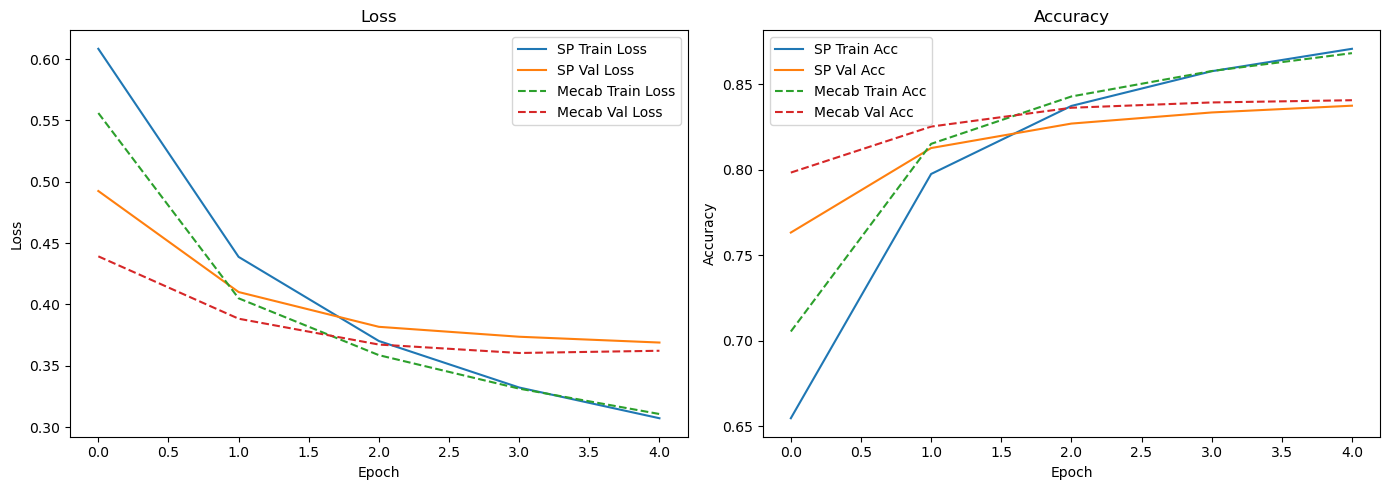

In [33]:
# 학습 곡선 그래프
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss 그래프
axes[0].plot(lstm_results[0], label='SP Train Loss')
axes[0].plot(lstm_results[1], label='SP Val Loss')
axes[0].plot(mecab_lstm_results[0], label='Mecab Train Loss', linestyle='--')
axes[0].plot(mecab_lstm_results[1], label='Mecab Val Loss', linestyle='--')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy 그래프
axes[1].plot(lstm_results[2], label='SP Train Acc')
axes[1].plot(lstm_results[3], label='SP Val Acc')
axes[1].plot(mecab_lstm_results[2], label='Mecab Train Acc', linestyle='--')
axes[1].plot(mecab_lstm_results[3], label='Mecab Val Acc', linestyle='--')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

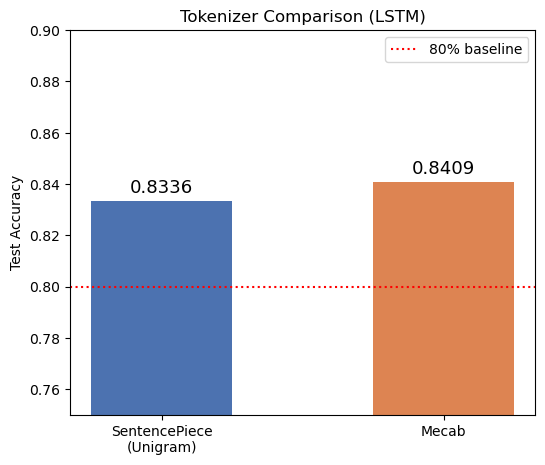

In [34]:
models = ['SentencePiece\n(Unigram)', 'Mecab']
accs = [sp_lstm_acc, mecab_lstm_acc]
colors = ['#4C72B0', '#DD8452']

plt.figure(figsize=(6, 5))
bars = plt.bar(models, accs, color=colors, width=0.5)

for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{acc:.4f}', ha='center', fontsize=13)

plt.ylim(0.75, 0.90)
plt.ylabel('Test Accuracy')
plt.title('Tokenizer Comparison (LSTM)')
plt.axhline(y=0.8, color='red', linestyle=':', label='80% baseline')
plt.legend()
plt.show()

---

## STEP 8: SentencePiece 옵션 변경 비교 분석

SentencePiece의 주요 옵션을 변경해가며 성능 변화를 확인

### 실험 설계
- **model_type**: `unigram` vs `bpe` (서브워드 학습 알고리즘)
  - unigram: EM 알고리즘으로 확률 기반 최적 분리
  - bpe: 빈도 높은 문자쌍을 반복 병합
- **vocab_size**: `4000` / `8000` / `16000` (사전 크기)
  - 작으면: 서브워드가 잘게 쪼개져 의미 손실 가능
  - 크면: Mecab처럼 통단어에 가까워지고 SentencePiece 장점 감소

기준 모델은 동일한 LSTM(word_vector_dim=64, hidden=32)을 사용하여 
순수하게 토크나이저 옵션 차이만 비교

In [35]:
# 실험 함수 정의
def run_sp_experiment(model_type, v_size, char_coverage=0.9995):
    """
    SentencePiece 옵션을 받아서 학습 → 토크나이징 → LSTM 학습 → 평가까지 수행
    """
    exp_name = f'{model_type}_v{v_size}_cc{char_coverage}'
    print(f'\n{"#"*50}')
    print(f'# 실험: {exp_name}')
    print(f'{"#"*50}')
    
    # 1) SentencePiece 학습
    prefix = f'nsmc_spm_{exp_name}'
    spm.SentencePieceTrainer.Train(
        f'--input={temp_file} '
        f'--model_prefix={prefix} '
        f'--vocab_size={v_size} '
        f'--model_type={model_type} '
        f'--character_coverage={char_coverage} '
        f'--pad_id=0 --unk_id=1 --bos_id=2 --eos_id=3'
    )
    
    # 2) 토크나이징
    X_tr, _, _ = sp_tokenize(f'{prefix}.model', train_corpus)
    X_te, _, _ = sp_tokenize(f'{prefix}.model', test_corpus)
    
    # 3) 패딩
    x_tr = torch.tensor(pad_sequences(X_tr, maxlen), dtype=torch.long)
    x_te = torch.tensor(pad_sequences(X_te, maxlen), dtype=torch.long)
    
    # 4) DataLoader
    train_loader_exp = DataLoader(
        TensorDataset(x_tr[20000:], partial_y_train_tensor), 
        batch_size=512, shuffle=True
    )
    val_loader_exp = DataLoader(
        TensorDataset(x_tr[:20000], y_val_tensor), 
        batch_size=512, shuffle=False
    )
    test_loader_exp = DataLoader(
        TensorDataset(x_te, y_test_tensor), 
        batch_size=512, shuffle=False
    )
    
    # 5) 기존 train_model은 전역 loader를 쓰므로, 여기서 직접 학습
    model = LSTMModel(v_size, word_vector_dim)
    optimizer = optim.Adam(model.parameters())
    loss_fn = nn.BCELoss()
    
    for epoch in range(5):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for inputs, labels in train_loader_exp:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_fn(outputs.squeeze(), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            predicted = (outputs.squeeze() > 0.5).float()
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
        
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader_exp:
                outputs = model(inputs)
                predicted = (outputs.squeeze() > 0.5).float()
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)
        
        print(f'Epoch {epoch+1}/5 - '
              f'Train Acc: {correct/total:.4f} - '
              f'Val Acc: {val_correct/val_total:.4f}')
    
    # 6) 테스트 평가
    test_acc = evaluate_model(model, test_loader_exp)
    return exp_name, test_acc

In [37]:
experiments = [
    ('unigram', 4000, 0.9995),
    ('unigram', 16000, 0.9995),
    ('bpe', 10000, 0.9995),
]

all_results = {}
# 이미 확인된 결과 추가
all_results['unigram_v10000'] = sp_lstm_acc  # STEP 6에서 나온 0.8336

for model_type, v_size, cc in experiments:
    name, acc = run_sp_experiment(model_type, v_size, cc)
    all_results[name] = acc


##################################################
# 실험: unigram_v4000_cc0.9995
##################################################
Epoch 1/5 - Train Acc: 0.6662 - Val Acc: 0.7721
Epoch 2/5 - Train Acc: 0.8051 - Val Acc: 0.8162
Epoch 3/5 - Train Acc: 0.8327 - Val Acc: 0.8243
Epoch 4/5 - Train Acc: 0.8453 - Val Acc: 0.8336
Epoch 5/5 - Train Acc: 0.8539 - Val Acc: 0.8369
Test Accuracy: 0.8299

##################################################
# 실험: unigram_v16000_cc0.9995
##################################################
Epoch 1/5 - Train Acc: 0.6326 - Val Acc: 0.7526
Epoch 2/5 - Train Acc: 0.7917 - Val Acc: 0.8075
Epoch 3/5 - Train Acc: 0.8382 - Val Acc: 0.8282
Epoch 4/5 - Train Acc: 0.8615 - Val Acc: 0.8363
Epoch 5/5 - Train Acc: 0.8784 - Val Acc: 0.8391
Test Accuracy: 0.8299

##################################################
# 실험: bpe_v10000_cc0.9995
##################################################
Epoch 1/5 - Train Acc: 0.6393 - Val Acc: 0.7537
Epoch 2/5 - Train Acc: 0.7950 - Va

In [39]:
# 결과 테이블
print('\n' + '=' * 60)
print('SentencePiece 옵션별 성능 비교 (LSTM 기준)')
print('=' * 60)
print(f'{"설정":35s} | {"Test Accuracy":>12s}')
print('-' * 60)
for name, acc in sorted(all_results.items(), key=lambda x: x[1], reverse=True):
    print(f'{name:35s} | {acc:>12.4f}')

print('-' * 60)
print(f'{"Mecab":35s} | {mecab_lstm_acc:>12.4f}')
print('=' * 60)


SentencePiece 옵션별 성능 비교 (LSTM 기준)
설정                                  | Test Accuracy
------------------------------------------------------------
unigram_v10000                      |       0.8336
bpe_v10000_cc0.9995                 |       0.8331
unigram_v4000_cc0.9995              |       0.8299
unigram_v16000_cc0.9995             |       0.8299
------------------------------------------------------------
Mecab                               |       0.8409


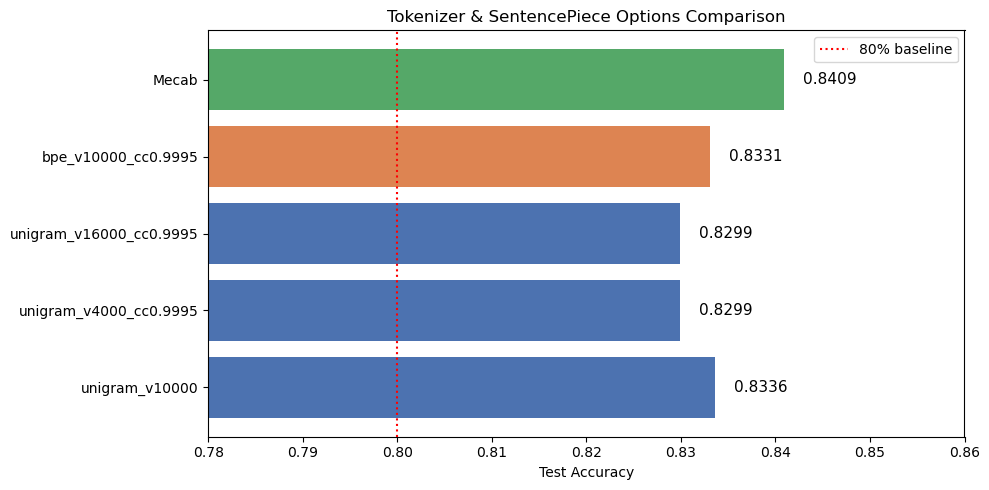

In [40]:
# 결과 시각화
names = list(all_results.keys()) + ['Mecab']
accs = list(all_results.values()) + [mecab_lstm_acc]
colors = ['#4C72B0' if 'unigram' in n else '#DD8452' if 'bpe' in n else '#55A868' for n in names]

plt.figure(figsize=(10, 5))
bars = plt.barh(names, accs, color=colors)

for bar, acc in zip(bars, accs):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{acc:.4f}', va='center', fontsize=11)

plt.xlim(0.78, 0.86)
plt.xlabel('Test Accuracy')
plt.title('Tokenizer & SentencePiece Options Comparison')
plt.axvline(x=0.8, color='red', linestyle=':', label='80% baseline')
plt.legend()
plt.tight_layout()
plt.show()

## 결론

### 성능 비교 요약
| 토크나이저 | Test Accuracy |
|-----------|--------------|
| Mecab + LSTM | 0.8409 |
| SP unigram v10000 | 0.8336 |
| SP bpe v10000 | 0.8331 |
| SP unigram v4000 | 0.8299 |
| SP unigram v16000 | 0.8299 |

### 분석
- **Mecab vs SentencePiece**: Mecab이 약 0.7%p 높지만, SentencePiece는 언어 지식 없이 데이터만으로 학습했음에도 거의 비슷한 성능을 보임
- **unigram vs bpe**: 동일 vocab_size(10000)에서 거의 동일한 성능. 이 데이터셋에서는 알고리즘 차이가 크지 않음
- **vocab_size**: 10000이 가장 좋았고, 4000(너무 잘게 쪼개짐)과 16000(사전이 너무 커짐) 모두 약간 하락
- **SentencePiece의 장점**: 별도의 형태소 분석기 설치나 불용어 사전이 필요 없고, 어떤 언어에도 동일하게 적용 가능


## 회고
- SentencePiece의 학습 원리를 이해하게 되었다
- Mecab 같은 형태소 분석기는 언어학 사전에 의존하는 반면, SentencePiece는 코퍼스만 있으면 어떤 언어든 적용 가능하다는 차이를 체감했다.
- vocab_size가 너무 작거나 크면 오히려 성능이 떨어진다는 것을 실험으로 확인했다.
- 토크나이저만 바꿔도 모델 성능에 영향을 주기 때문에, 전처리 단계의 중요성을 다시 느꼈다.
